<a href="https://colab.research.google.com/github/alifia07nisa/data-science-2026/blob/main/Pertemuan5_Alifia_Choirunnisa_250401020010.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [162]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

sns.set_style("whitegrid")

plt.rcParams['figure.facecolor'] = 'white'

In [163]:
#LOAD & INSPECT DATASET
df = sns.load_dataset('penguins') # ganti sesuai pilihan
print(df.shape)
df = df.dropna()
df.head()


(344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [164]:
print(df.shape)
print(df.dtypes)
print(df.describe().round(2))
df.isnull().sum()

(333, 7)
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count          333.00         333.00             333.00       333.00
mean            43.99          17.16             200.97      4207.06
std              5.47           1.97              14.02       805.22
min             32.10          13.10             172.00      2700.00
25%             39.50          15.60             190.00      3550.00
50%             44.50          17.30             197.00      4050.00
75%             48.60          18.70             213.00      4775.00
max             59.60          21.50             231.00      6300.00


,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


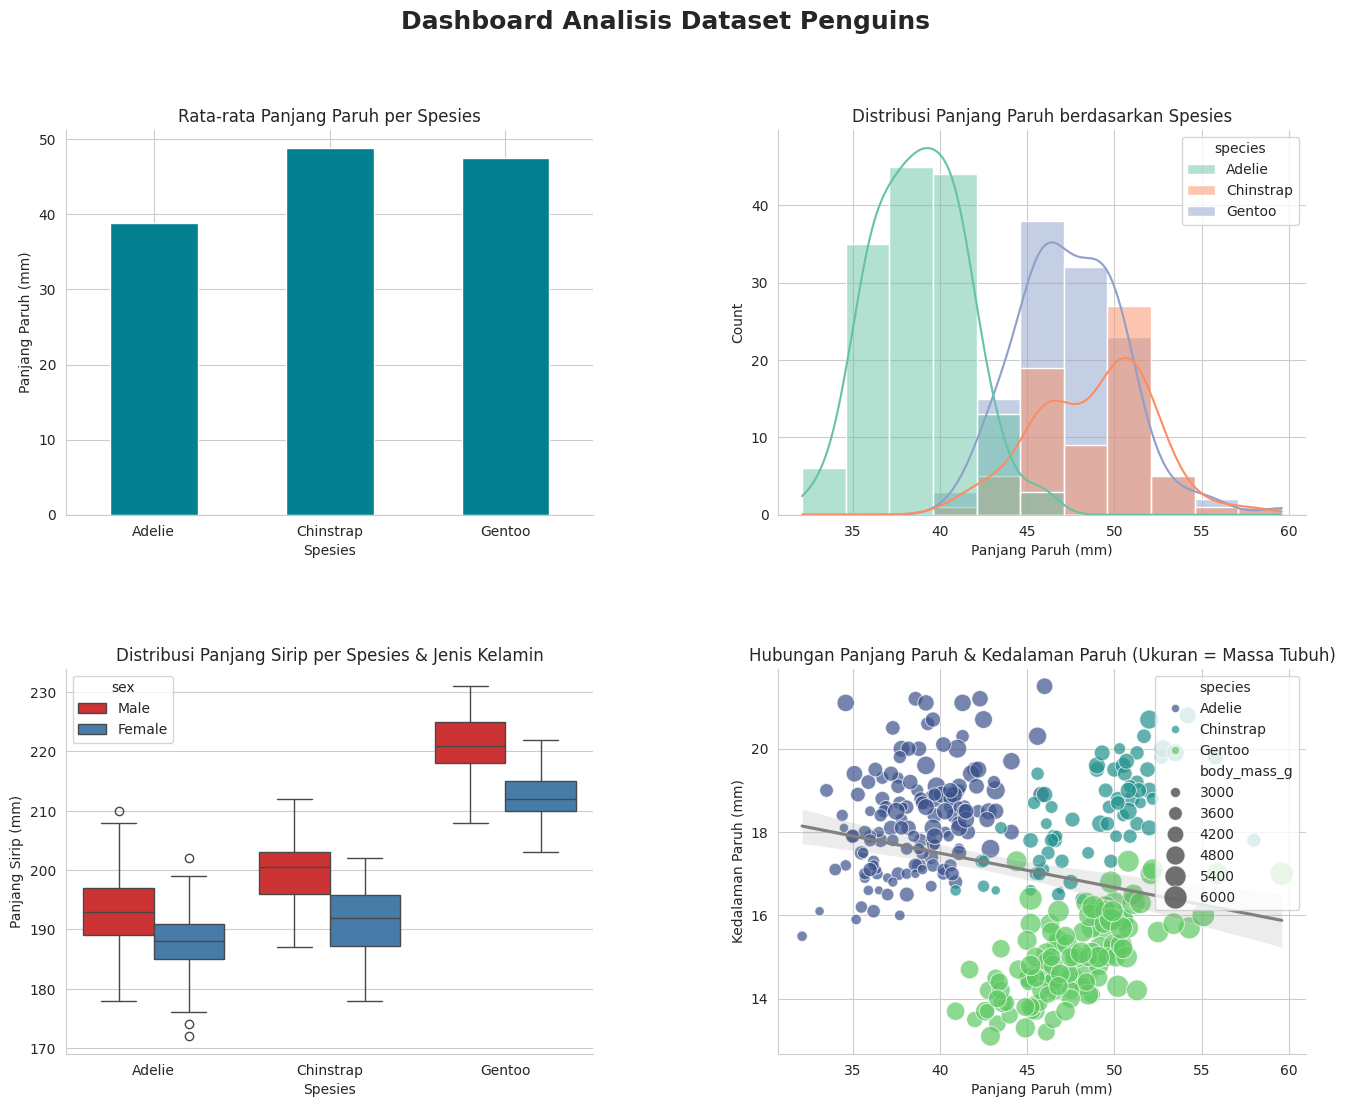

Dashboard tersimpan sebagai dashboard_penguins.png


In [165]:
#SETUP FIGURE LAYOUT
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Dataset Penguins', fontsize=18, fontweight='bold', y=0.98)

# Grid 2 x 2 subplot
gs = gridspec.GridSpec(2, 2, figure=fig,
                       hspace=0.4, wspace=0.35)

ax1 = fig.add_subplot(gs[0, 0])  # kiri atas
ax2 = fig.add_subplot(gs[0, 1])  # kanan atas
ax3 = fig.add_subplot(gs[1, 0])  # kiri bawah
ax4 = fig.add_subplot(gs[1, 1])  # kanan bawah

#GRAFIK 1: Bar Chart
avg_by_species = df.groupby('species')['bill_length_mm'].mean()
avg_by_species.plot(kind='bar', ax=ax1, color='#028090',edgecolor='white')
ax1.set_title('Rata-rata Panjang Paruh per Spesies')
ax1.set_xlabel('Spesies'); ax1.set_ylabel('Panjang Paruh (mm)')
ax1.tick_params(axis='x', rotation=0)
ax1.spines[['top','right']].set_visible(False)

#GRAFIK 2: Histogram + KDE
sns.histplot(data=df, x='bill_length_mm', hue='species', kde=True, palette='Set2', ax=ax2)
ax2.set_title('Distribusi Panjang Paruh berdasarkan Spesies')
ax2.set_xlabel('Panjang Paruh (mm)')
ax2.spines[['top','right']].set_visible(False)

#GRAFIK 3: Boxplot
sns.boxplot(data=df, x='species', y='flipper_length_mm', hue='sex', palette='Set1', ax=ax3)
ax3.set_title('Distribusi Panjang Sirip per Spesies & Jenis Kelamin')
ax3.set_xlabel('Spesies')
ax3.set_ylabel('Panjang Sirip (mm)')
ax3.spines[['top','right']].set_visible(False)

#GRAFIK 4: Scatter Plot
sns.scatterplot(data=df, x='bill_length_mm', y='bill_depth_mm',
                hue='species', size='body_mass_g', sizes=(30,300), palette='viridis', alpha=0.7, ax=ax4)
sns.regplot(data=df, x='bill_length_mm', y='bill_depth_mm', scatter=False, color='gray', ax=ax4)
ax4.set_title('Hubungan Panjang Paruh & Kedalaman Paruh (Ukuran = Massa Tubuh)')
ax4.set_xlabel('Panjang Paruh (mm)')
ax4.set_ylabel('Kedalaman Paruh (mm)')
ax4.spines[['top','right']].set_visible(False)

#EKSPOR
plt.savefig('dashboard_penguins.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard tersimpan sebagai dashboard_penguins.png')
